In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random

# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve

np.random.seed(0)
X = np.linspace(-5, 5, 50) # 50 points between -5 and 5
Y = 2 * X**2 + 3 * X + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise


In [2]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data

degree = 2 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

Polynomial Coefficients:  [2.09218103 1.58837751 0.60606342]


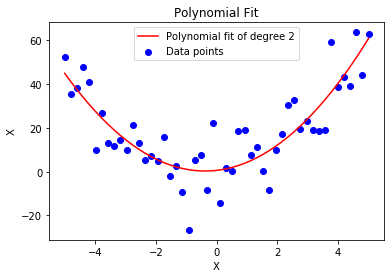

In [3]:
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(X)

# Step 4: Plotting the results
plt.scatter(X, Y, color='blue', label='Data points') # Original data points
plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')

# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('X')
plt.ylabel('X')
plt.legend()
plt.show()

In [4]:
# Mean Squared Error (MSE)
mse = np.mean((Y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 108.8860
R-squared: 0.7236


Slope: 1.1301984888479308, Intercept: -0.08076612464132996


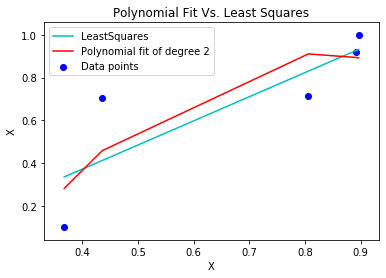

Mean Squared Error for PolyFit: 0.0288
Mean Squared Error for Least Squares: 0.0316
R-squared for PolyFit: 0.7101
R-squared for Least Squares: 0.6815
Polynomial fitting results in the better fit


In [32]:
#In-Class Challenge 10

# Data points
X = np.sort(np.random.rand(5))
Y = np.sort(np.random.rand(5))
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

leastsquaresY = m*X + c

plt.scatter(X, Y, color='blue', label='Data points') # Plotting original data points


plt.plot(X, leastsquaresY, 'c', label='LeastSquares')

#polyFit
degree = 2 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(X)

plt.plot(X, y_pred, color='red', label=f'Polynomial fit of degree {degree}')

# Fitted curve
plt.title('Polynomial Fit Vs. Least Squares')
plt.xlabel('X')
plt.ylabel('X')
plt.legend()

plt.show()


#MSE Comparison
msePoly = np.mean((Y - y_pred)**2)
mseLS = np.mean((Y - leastsquaresY)**2)

print(f'Mean Squared Error for PolyFit: {msePoly:.4f}')
print(f'Mean Squared Error for Least Squares: {mseLS:.4f}')


#R-Squared Comparison
ss_total = np.sum((Y - np.mean(Y))**2)
ss_resPoly = np.sum((Y - y_pred)**2)
r_squaredPoly = 1 - (ss_resPoly / ss_total)
print(f'R-squared for PolyFit: {r_squaredPoly:.4f}')

ss_resLS = np.sum((Y - leastsquaresY)**2)
r_squaredLS = 1 - (ss_resLS / ss_total)
print(f'R-squared for Least Squares: {r_squaredLS:.4f}')

if(msePoly < mseLS):
    print("Polynomial fitting results in the better fit")
elif(msePoly > mseLS):
    print("Least squares results in the better fit")
elif(msePoly == mseLS):
    print("Polynomial fitting and least squares have an equal fit")

In [33]:
#PolyFit of varying degrees
for degree in range(1,5):
    coefficients = np.polyfit(X, Y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(X)

    #MSE and R-Squared Comparison
    msePoly = np.mean((Y - y_pred)**2)
    print(f'Mean Squared Error for PolyFit degree {degree}: {msePoly:.4f}')

    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_resPoly = np.sum((Y - y_pred)**2)
    r_squaredPoly = 1 - (ss_resPoly / ss_total)
    print(f'R-squared for PolyFit degree {degree}: {r_squaredPoly:.4f}\n')


Mean Squared Error for PolyFit degree 1: 0.0316
R-squared for PolyFit degree 1: 0.6815

Mean Squared Error for PolyFit degree 2: 0.0288
R-squared for PolyFit degree 2: 0.7101

Mean Squared Error for PolyFit degree 3: 0.0003
R-squared for PolyFit degree 3: 0.9970

Mean Squared Error for PolyFit degree 4: 0.0000
R-squared for PolyFit degree 4: 1.0000



In [36]:
#Challenge 10: Part C
degree = 4
def create_vandermonde_matrix(X, degree):
    V = np.vander(X, N=degree+1, increasing=True)
    return V

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, Y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)


ValueError: shapes (3,3) and (5,) not aligned: 3 (dim 1) != 5 (dim 0)